In [ ]:
#Ejemplo de pronóstico
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
#2. Generación de datos de ejemplo de la TRM del último año
# Datos adaptados de: https://totoro.banrep.gov.co/analytics/saw.dll?Go&Action=prompt&path=%2Fshared%2FSeries%20Estad%C3%ADsticas_T%2F1.%20Tasa%20de%20Cambio%20Peso%20Colombiano%2F1.1%20TRM%20-%20Disponible%20desde%20el%2027%20de%20noviembre%20de%201991%2F1.1.16.TCM_Serie%20historica_ultimos_doce%20meses&Options=rdf&lang=es

import csv
import pandas as pd

# Ruta a tu archivo de etiquetas
archivo_csv = "1.1.16.TCM_Serie historica_ultimos_doce meses.csv"

# Leer el archivo CSV en un DataFrame especificando el delimitador
df = pd.read_csv(archivo_csv, delimiter=';', decimal=',')

# Asegurar que la columna 'Fecha' esté en formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
df = df.drop(columns=[';'])
# Eliminar espacios en los nombres de las columnas si es necesario
df.columns = df.columns.str.strip()
# Reemplazar comas por puntos y convertir a float
# Eliminar los puntos de los miles y reemplazar comas por puntos decimales
df['TRM'] = df['TRM'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)

# Verificar resultados
print(df.head())
print("columnas", df.columns)
print("tipo", df.dtypes)  # Verifica el tipo de datos de la columna 'TRM'

       Fecha      TRM
0 2024-08-14  4038.87
1 2024-08-13  4063.26
2 2024-08-12  4064.51
3 2024-08-11  4064.51
4 2024-08-10  4064.51
columnas Index(['Fecha', 'TRM'], dtype='object')
tipo Fecha    datetime64[ns]
TRM             float64
dtype: object


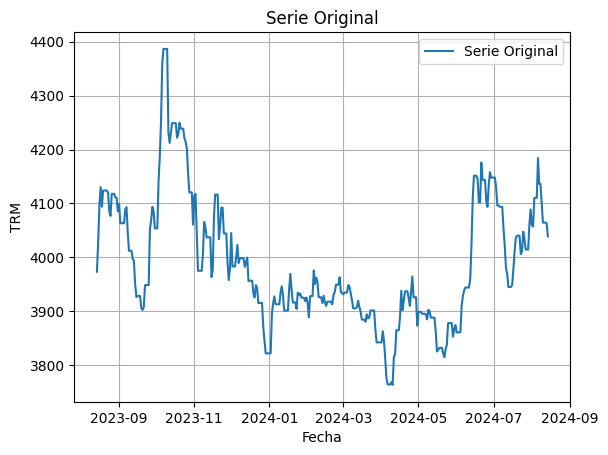

In [ ]:
# 3. Gráfica de la serie original
plt.plot(df['Fecha'], df['TRM'], label='Serie Original')
plt.title('Serie Original')
plt.xlabel('Fecha')
plt.ylabel('TRM')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Descomposición de la serie de tiempo

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Como se tiene el DataFrame df con las columnas 'Fecha' y 'TRM'

# Configurar la columna 'Fecha' como índice
df.set_index('Fecha', inplace=True)

# Asegurarse de que el índice sea un DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("El índice del DataFrame debe ser un DatetimeIndex.")

#Nota: Después de establecer la columna 'Fecha' como índice, no estará disponible
#como una columna en el DataFrame df. Por tanto, debe volverse a ejecutar todo el código
#porque, cuando se intenta acceder a df['Fecha'],
#se produce un KeyError porque la columna 'Fecha' no existe en el DataFrame.

# Establecer la frecuencia del índice si es necesario
df = df.asfreq('D')  # 'D' para datos diarios, ajusta si es diferente (por ejemplo, 'W' para semanal, 'M' para mensual)

# Seleccionar la serie de tiempo
ts = df['TRM']


In [ ]:
#Dividir los datos de entrenamiento y prueba
train_data, test_data = train_test_split(ts, test_size=0.3, shuffle=False)

In [ ]:
#Ajustar el modelo ARIMA
model = ARIMA(train_data, order=(10,1,10))
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#Realizar el pronóstico
forescast = model_fit.forecast(steps=len(test_data))

In [ ]:
#Calcular el error absoluto medio (MAE)
mae = mean_absolute_error(test_data, forescast)
print('Error absoluto medio (MAE):', mae)

Error absoluto medio (MAE): 103.16198073234249


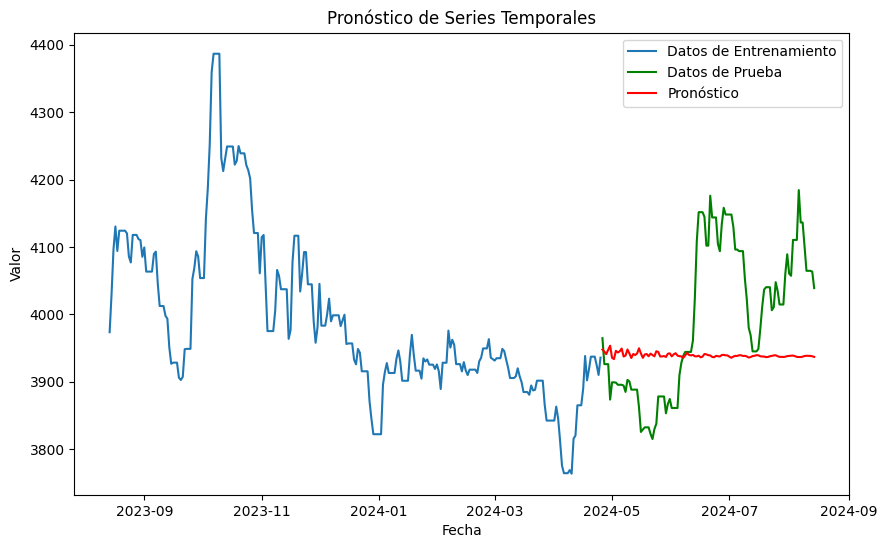

In [ ]:
#Gráfica de los datos originales y el pronóstico
plt.figure(figsize=(10,6))
plt.plot(train_data, label='Datos de Entrenamiento')
plt.plot(test_data, label='Datos de Prueba', color='green')
plt.plot(test_data.index, forescast, label='Pronóstico', color='red')
plt.legend()
plt.title('Pronóstico de Series Temporales')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.show()

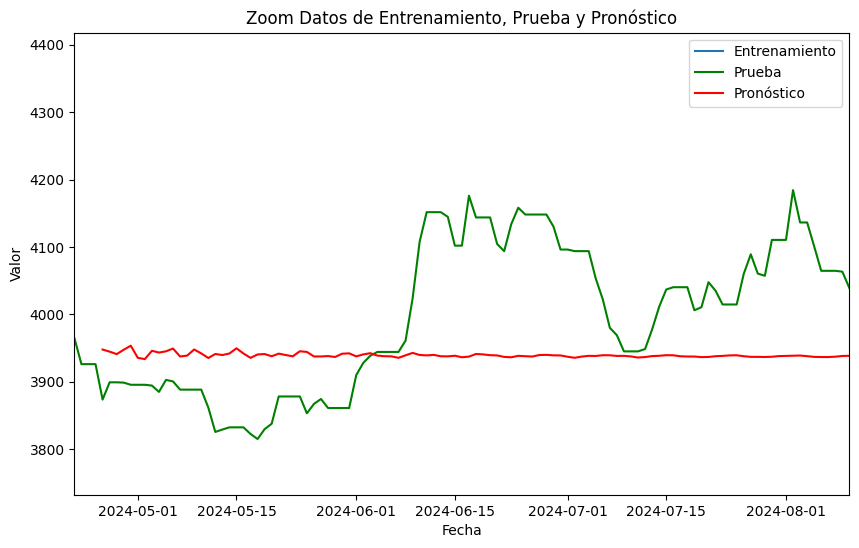

In [ ]:
#Zoom de datos de prueba y pronóstico
# Hacer pronósticos
forecast = model_fit.forecast(steps=len(test_data))

# Configurar las fechas para los datos de entrenamiento, prueba y pronóstico
train_dates = pd.date_range(start='2023-08-10', periods=len(train_data), freq='D')  # Ajusta las fechas
test_dates = pd.date_range(start=train_dates[-1] + pd.Timedelta(days=1), periods=len(test_data), freq='D')

# Crear la serie de tiempo para los pronósticos
forecast_dates = test_dates
forecast_series = pd.Series(forecast, index=forecast_dates)

# Plotear los datos de entrenamiento, prueba y pronóstico
plt.figure(figsize=(10, 6))
plt.plot(train_dates, train_data, label='Entrenamiento')
plt.plot(test_dates, test_data, label='Prueba', color='green')
plt.plot(forecast_dates, forecast_series, label='Pronóstico', color='red')

# Hacer zoom en la parte de la gráfica donde empiezan los datos de prueba y pronóstico
plt.xlim([test_dates[0], test_dates[-1]])  # Establecer límites del eje x

# Añadir títulos y leyenda
plt.title('Zoom Datos de Entrenamiento, Prueba y Pronóstico')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()

# Mostrar la gráfica
plt.show()

Longitud de train_data: 111
Longitud de errors: 111


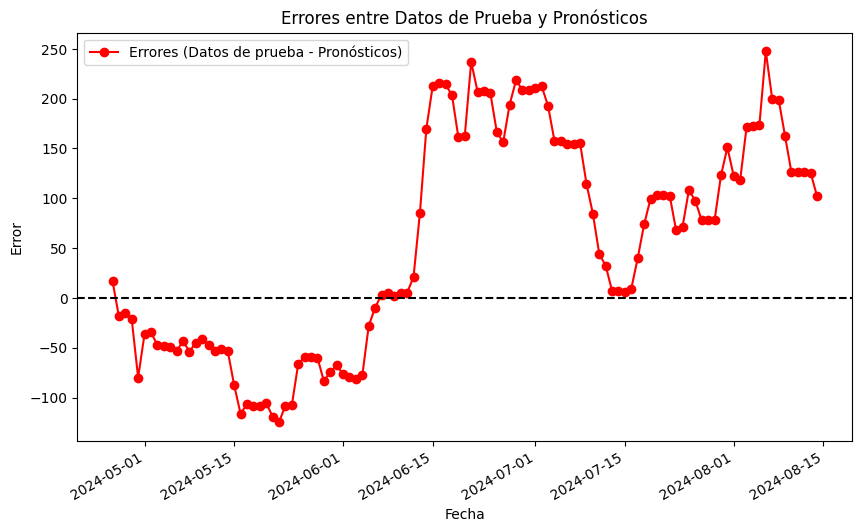

In [ ]:
import matplotlib.pyplot as plt

# Como 'train_data' contiene los valores reales de entrenamiento
# y 'forecast_data' contiene los valores pronosticados

# Calcular los errores (residuales) entre los datos reales y los pronósticos
errors = test_data - forecast

print(f"Longitud de train_data: {len(train_data)}")
print(f"Longitud de errors: {len(errors)}")

# Asegúrando que train_data y errors tengan la misma longitud
min_length = min(len(test_data), len(errors))
train_data = test_data[:min_length]
errors = errors[:min_length]

# Graficar los errores
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, errors, marker='o', linestyle='-', color='red', label='Errores (Datos de prueba - Pronósticos)')

# Añadir títulos y etiquetas
plt.title('Errores entre Datos de Prueba y Pronósticos')
plt.xlabel('Fecha')
plt.ylabel('Error')
plt.axhline(y=0, color='black', linestyle='--')  # Línea horizontal en y=0 para referencia
plt.legend()

# Rotar las etiquetas de las fechas si es necesario
plt.gcf().autofmt_xdate()

# Mostrar la gráfica
plt.show()

# Mostrar la gráfica
plt.show()